# Direct Cellpose Detection on Volume

Run Cellpose directly on each z-plane of a volume, bypassing Suite2p's wrapper.
Saves both per-plane and combined volumetric results.

**It is helpful to put vd0 and vd1 into separate folders**

![](./media/folder.png)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import time

from cellpose import models, core
from mbo_utilities import imread, imwrite

print(f"GPU available: {core.use_gpu()}")

GPU available: True


## Configuration

In [30]:
help(mbo.imwrite)

Help on function imwrite in module mbo_utilities.writer:

imwrite(lazy_array, outpath: 'str | Path', ext: 'str' = '.tiff', planes: 'list | tuple | None' = None, num_frames: 'int | None' = None, register_z: 'bool' = False, roi: 'int | Sequence[int] | None' = None, metadata: 'dict | None' = None, overwrite: 'bool' = False, order: 'list | tuple' = None, target_chunk_mb: 'int' = 100, progress_callback: 'Callable | None' = None, debug: 'bool' = False, shift_vectors: 'np.ndarray | None' = None, output_name: 'str | None' = None, output_suffix: 'str | None' = None, **kwargs)
    Write a supported lazy imaging array to disk.

    This function handles writing multi-dimensional imaging data to various formats,
    with support for ROI selection, z-plane registration, chunked streaming, and
    format conversion. Use with `imread()` to load and convert imaging data.

    Parameters
    ----------
    lazy_array : object
        One of the supported lazy array readers providing `.shape`, `.metadat

In [ ]:
vd0 = imread(r"D:\cj\2025-11-21\raw\vdaq0")
vd0.shape

imwrite(
    lazy_array=vd0,
    outpath=r"D:\cj\2025-11-21\volume",
    ext=".zarr",
    planes=None,
    roi=None,
    num_frames=None,
    metadata={"dz": 15},
    output_suffix="_vdaq0"
)

Counting frames:   0%|          | 0/1 [00:00<?, ?it/s]

File D:\cj\2025-11-21\volume\plane01_vdaq0.zarr already exists. Skipping write.
File D:\cj\2025-11-21\volume\plane02_vdaq0.zarr already exists. Skipping write.


WindowsPath('D:/cj/2025-11-21/volume')

In [ ]:
vd1 = imread(r"D:\cj\2025-11-21\raw\vdaq1")
imwrite(
    lazy_array=vd1,
    outpath=r"D:\cj\2025-11-21\volume",
    ext=".zarr",
    planes=None,
    roi=None,
    num_frames=None,
    metadata={"dz": 15},
    output_suffix="_vdaq1"
)

Counting frames:   0%|          | 0/1 [00:00<?, ?it/s]

Saving plane01_vdaq1.zarr:   0%|          | 0/11 [00:00<?, ?it/s]

Saving plane02_vdaq1.zarr:   0%|          | 0/11 [00:00<?, ?it/s]

WindowsPath('D:/cj/2025-11-21/volume')

In [17]:
# Input volume
VOLUME_PATH = Path(r"D:\cj\2025-11-21\volume")
data = imread(VOLUME_PATH)
data.shape

(970, 4, 772, 735)

In [32]:
# Output directory
OUTPUT_DIR = VOLUME_PATH.parent / "cellpose_results_norm"
OUTPUT_DIR.mkdir(exist_ok=True)

# Cellpose parameters
DIAMETER = 2
CELLPROB_THRESHOLD = -6.0
FLOW_THRESHOLD = 0.0

# Size filtering (in pixels)
MIN_CELL_SIZE = 4
MAX_CELL_SIZE = 100

print(f"Input: {VOLUME_PATH}")
print(f"Output: {OUTPUT_DIR}")
print(f"\nCellpose params:")
print(f"  diameter: {DIAMETER}")
print(f"  cellprob_threshold: {CELLPROB_THRESHOLD}")
print(f"  flow_threshold: {FLOW_THRESHOLD}")
print(f"\nSize filter: {MIN_CELL_SIZE} - {MAX_CELL_SIZE} pixels")

Input: D:\cj\2025-11-21\volume
Output: D:\cj\2025-11-21\cellpose_results_norm

Cellpose params:
  diameter: 2
  cellprob_threshold: -6.0
  flow_threshold: 0.0

Size filter: 4 - 100 pixels


## Load Volume

In [33]:
print(f"Shape: {data.shape}")
print(f"Dtype: {data.dtype}")

if data.ndim == 4:
    n_frames, n_planes, Ly, Lx = data.shape
    print(f"\n4D volume: {n_frames} frames, {n_planes} planes, {Ly}x{Lx}")
elif data.ndim == 3:
    n_frames, Ly, Lx = data.shape
    n_planes = 1
    print(f"\n3D volume: {n_frames} frames, {Ly}x{Lx}")
else:
    raise ValueError(f"Expected 3D or 4D array, got {data.ndim}D")

Shape: (970, 4, 772, 735)
Dtype: int16

4D volume: 970 frames, 4 planes, 772x735


## Compute Projections

In [34]:
def compute_projections(data, plane_idx=None):
    """Compute max and mean projections for a plane."""
    if data.ndim == 4:
        plane_data = data[:, plane_idx, :, :]
    else:
        plane_data = data

    max_proj = np.max(plane_data, axis=0).astype(np.float32)
    mean_img = np.mean(plane_data, axis=0).astype(np.float32)
    return max_proj, mean_img

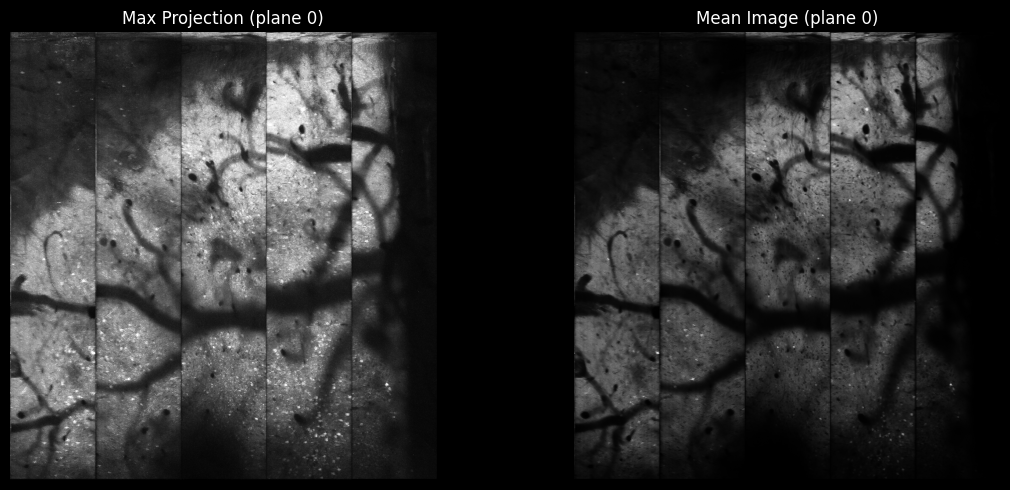

In [21]:
# Preview first plane
if n_planes > 1:
    max_proj, mean_img = compute_projections(data, 0)
else:
    max_proj, mean_img = compute_projections(data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(max_proj, cmap='gray')
axes[0].set_title('Max Projection (plane 0)')
axes[1].imshow(mean_img, cmap='gray')
axes[1].set_title('Mean Image (plane 0)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Helper Functions

In [22]:
def normalize99(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

def masks_to_stat(masks, min_size=None, max_size=None):
    """Convert Cellpose masks to Suite2p-style stat array with size filtering."""
    stat = []
    n_cells = masks.max()

    for i in range(1, n_cells + 1):
        ypix, xpix = np.where(masks == i)
        npix = len(ypix)

        if min_size is not None and npix < min_size:
            continue
        if max_size is not None and npix > max_size:
            continue

        lam = np.ones(npix, dtype=np.float32) / npix
        stat.append({
            'ypix': ypix.astype(np.int32),
            'xpix': xpix.astype(np.int32),
            'lam': lam,
            'npix': npix,
            'med': [np.median(ypix), np.median(xpix)],
        })

    return np.array(stat, dtype=object)

def stat_to_mask(stat, Ly, Lx):
    """Convert stat array back to labeled mask."""
    mask = np.zeros((Ly, Lx), dtype=np.uint16)
    for i, s in enumerate(stat):
        mask[s['ypix'], s['xpix']] = i + 1
    return mask

def random_colors_for_mask(mask):
    from matplotlib.colors import hsv_to_rgb
    n_cells = mask.max()
    if n_cells == 0:
        return np.zeros((*mask.shape, 3), dtype=np.float32)

    np.random.seed(42)
    hues = np.random.rand(n_cells + 1)
    sats = 0.7 + 0.3 * np.random.rand(n_cells + 1)
    vals = 0.8 + 0.2 * np.random.rand(n_cells + 1)

    colors = np.zeros((n_cells + 1, 3))
    for i in range(1, n_cells + 1):
        colors[i] = hsv_to_rgb([hues[i], sats[i], vals[i]])

    return colors[mask].astype(np.float32)

def mask_overlay(img, mask, alpha=0.5):
    img_norm = normalize99(img)
    rgb = np.stack([img_norm] * 3, axis=-1).astype(np.float32)

    if mask.max() > 0:
        colors = random_colors_for_mask(mask)
        mask_px = mask > 0
        rgb[mask_px] = (1 - alpha) * rgb[mask_px] + alpha * colors[mask_px]

    return np.clip(rgb, 0, 1)

## Run Cellpose on All Planes

In [ ]:
norm = True

model = models.CellposeModel(gpu=core.use_gpu())

plane_results = {}

for z in tqdm(range(n_planes), desc="Processing planes"):
    plane_dir = OUTPUT_DIR / f"plane{z:02d}"
    plane_dir.mkdir(exist_ok=True)

    # Compute projections
    if n_planes > 1:
        max_proj, mean_img = compute_projections(data, z)
    else:
        max_proj, mean_img = compute_projections(data)

    # Run Cellpose on max projection
    img = normalize99(max_proj) if norm else max_proj


    t0 = time.perf_counter()
    masks, flows, styles = model.eval(
        img,
        diameter=DIAMETER,
        cellprob_threshold=CELLPROB_THRESHOLD,
        flow_threshold=FLOW_THRESHOLD,
    )
    elapsed = time.perf_counter() - t0

    n_raw = masks.max()

    # Convert to stat with size filtering
    stat = masks_to_stat(masks, min_size=MIN_CELL_SIZE, max_size=MAX_CELL_SIZE)
    n_filtered = len(stat)

    # Create iscell array (all accepted)
    iscell = np.ones((len(stat), 2), dtype=np.float32)
    iscell[:, 1] = 0.5

    # Build ops dict
    ops = {
        'Ly': Ly,
        'Lx': Lx,
        'plane': z,
        'nframes': n_frames,
        'max_proj': max_proj,
        'meanImg': mean_img,
        'diameter': DIAMETER,
        'cellprob_threshold': CELLPROB_THRESHOLD,
        'flow_threshold': FLOW_THRESHOLD,
        'min_cell_size': MIN_CELL_SIZE,
        'max_cell_size': MAX_CELL_SIZE,
        'n_cells_raw': n_raw,
        'n_cells_filtered': n_filtered,
        'detection_time': elapsed,
    }

    # Save plane results
    np.save(plane_dir / "ops.npy", ops)
    np.save(plane_dir / "stat.npy", stat)
    np.save(plane_dir / "iscell.npy", iscell)
    np.save(plane_dir / "masks_raw.npy", masks)

    plane_results[z] = {
        'n_raw': n_raw,
        'n_filtered': n_filtered,
        'time': elapsed,
        'stat': stat,
        'masks': masks,
        'max_proj': max_proj,
        'dir': plane_dir,
    }

    print(f"  Plane {z}: {n_raw} raw -> {n_filtered} filtered ({elapsed:.1f}s)")

Processing planes:   0%|          | 0/4 [00:00<?, ?it/s]

## Save Volumetric Results

In [24]:
# Combine all planes into volumetric stat with plane index
volume_stat = []
cell_id = 0

for z in range(n_planes):
    r = plane_results[z]
    for s in r['stat']:
        s_copy = s.copy()
        s_copy['iplane'] = z
        s_copy['original_id'] = cell_id
        volume_stat.append(s_copy)
        cell_id += 1

volume_stat = np.array(volume_stat, dtype=object)

# Volume iscell
volume_iscell = np.ones((len(volume_stat), 2), dtype=np.float32)
volume_iscell[:, 1] = 0.5

# Volume ops
volume_ops = {
    'Ly': Ly,
    'Lx': Lx,
    'n_planes': n_planes,
    'nframes': n_frames,
    'diameter': DIAMETER,
    'cellprob_threshold': CELLPROB_THRESHOLD,
    'flow_threshold': FLOW_THRESHOLD,
    'min_cell_size': MIN_CELL_SIZE,
    'max_cell_size': MAX_CELL_SIZE,
    'n_cells_total': len(volume_stat),
    'cells_per_plane': [plane_results[z]['n_filtered'] for z in range(n_planes)],
}

# Save
np.save(OUTPUT_DIR / "volume_ops.npy", volume_ops)
np.save(OUTPUT_DIR / "volume_stat.npy", volume_stat)
np.save(OUTPUT_DIR / "volume_iscell.npy", volume_iscell)

print(f"Volume results: {len(volume_stat)} total cells across {n_planes} planes")
print(f"Saved to: {OUTPUT_DIR}")

Volume results: 2140 total cells across 4 planes
Saved to: D:\cj\2025-11-21\cellpose_results


## Results Summary

In [25]:
print("\n" + "="*60)
print("DETECTION SUMMARY")
print("="*60)
print(f"{'Plane':>6} {'Raw':>8} {'Filtered':>10} {'Time':>8}")
print("-"*40)

total_raw = 0
total_filtered = 0
total_time = 0

for z in range(n_planes):
    r = plane_results[z]
    print(f"{z:>6} {r['n_raw']:>8} {r['n_filtered']:>10} {r['time']:>7.1f}s")
    total_raw += r['n_raw']
    total_filtered += r['n_filtered']
    total_time += r['time']

print("-"*40)
print(f"{'Total':>6} {total_raw:>8} {total_filtered:>10} {total_time:>7.1f}s")
print(f"\nFiltering removed {total_raw - total_filtered} cells ({100*(total_raw-total_filtered)/total_raw:.1f}%)")


DETECTION SUMMARY
 Plane      Raw   Filtered     Time
----------------------------------------
     0      442        435   116.0s
     1      410        399   116.8s
     2      671        667   116.9s
     3      644        639   116.8s
----------------------------------------
 Total     2167       2140   466.5s

Filtering removed 27 cells (1.2%)


## Visualize Results

In [ ]:
# Show first few planes with zoom insets
n_show = min(4, n_planes)
fig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 8))
if n_show == 1:
    axes = axes.reshape(2, 1)

for i in range(n_show):
    r = plane_results[i]

    # Raw masks
    axes[0, i].imshow(mask_overlay(r['max_proj'], r['masks']))
    axes[0, i].set_title(f"Plane {i}: {r['n_raw']} raw")
    axes[0, i].axis('off')

    # Filtered masks
    filtered_mask = stat_to_mask(r['stat'], Ly, Lx)
    axes[1, i].imshow(mask_overlay(r['max_proj'], filtered_mask))
    axes[1, i].set_title(f"Plane {i}: {r['n_filtered']} filtered")
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Raw', fontsize=12)
axes[1, 0].set_ylabel('Filtered', fontsize=12)

plt.suptitle(f'Cellpose Detection (size filter: {MIN_CELL_SIZE}-{MAX_CELL_SIZE}px)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'detection_preview.png', dpi=150)
plt.show()

In [ ]:
# Zoom-in views for better cell visibility
# Pick a region with cells from plane 2 (has most cells)
plane_idx = 2
r = plane_results[plane_idx]
filtered_mask = stat_to_mask(r['stat'], Ly, Lx)

# Find region with highest cell density for zoom
# Compute local cell density in 100x100 blocks
block = 100
density = np.zeros((Ly // block, Lx // block))
for by in range(density.shape[0]):
    for bx in range(density.shape[1]):
        region = filtered_mask[by*block:(by+1)*block, bx*block:(bx+1)*block]
        density[by, bx] = len(np.unique(region)) - 1  # -1 for background

best_block = np.unravel_index(np.argmax(density), density.shape)
cy, cx = best_block[0] * block + block//2, best_block[1] * block + block//2

# Zoom regions: 200x200 and 100x100
zoom_sizes = [200, 100]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Full view
axes[0, 0].imshow(mask_overlay(r['max_proj'], filtered_mask))
axes[0, 0].set_title(f'Plane {plane_idx}: Full View ({r["n_filtered"]} cells)')
axes[0, 0].axis('off')

# Draw zoom boxes
for i, zs in enumerate(zoom_sizes):
    rect = plt.Rectangle((cx - zs//2, cy - zs//2), zs, zs,
                          fill=False, edgecolor=['yellow', 'cyan'][i], linewidth=2)
    axes[0, 0].add_patch(rect)

# Zoomed views
for i, zs in enumerate(zoom_sizes):
    y1, y2 = max(0, cy - zs//2), min(Ly, cy + zs//2)
    x1, x2 = max(0, cx - zs//2), min(Lx, cx + zs//2)

    zoom_img = r['max_proj'][y1:y2, x1:x2]
    zoom_mask = filtered_mask[y1:y2, x1:x2]

    axes[0, i+1].imshow(mask_overlay(zoom_img, zoom_mask))
    n_cells_zoom = len(np.unique(zoom_mask)) - 1
    axes[0, i+1].set_title(f'Zoom {zs}x{zs} ({n_cells_zoom} cells)')
    axes[0, i+1].axis('off')

# Bottom row: grayscale with cell outlines for clarity
axes[1, 0].imshow(normalize99(r['max_proj']), cmap='gray')
axes[1, 0].set_title('Max Projection (grayscale)')
axes[1, 0].axis('off')

for i, zs in enumerate(zoom_sizes):
    y1, y2 = max(0, cy - zs//2), min(Ly, cy + zs//2)
    x1, x2 = max(0, cx - zs//2), min(Lx, cx + zs//2)

    zoom_img = r['max_proj'][y1:y2, x1:x2]
    zoom_mask = filtered_mask[y1:y2, x1:x2]

    # Show grayscale with cell outlines
    from scipy import ndimage
    outlines = np.zeros_like(zoom_mask, dtype=bool)
    for cell_id in range(1, zoom_mask.max() + 1):
        cell_binary = zoom_mask == cell_id
        if cell_binary.any():
            dilated = ndimage.binary_dilation(cell_binary)
            outline = dilated & ~cell_binary
            outlines |= outline

    axes[1, i+1].imshow(normalize99(zoom_img), cmap='gray')
    axes[1, i+1].contour(outlines, colors='lime', linewidths=0.5)
    axes[1, i+1].set_title(f'Zoom {zs}x{zs} (outlines)')
    axes[1, i+1].axis('off')

plt.suptitle(f'Zoom Views - Plane {plane_idx} (center at y={cy}, x={cx})', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'zoom_views.png', dpi=200)
plt.show()

print(f"Zoom center: ({cy}, {cx}) - region with {density[best_block]:.0f} cells in {block}x{block} block")

In [ ]:
# Compare all planes at same zoom region (150x150)
zoom_size = 150
fig, axes = plt.subplots(2, n_planes, figsize=(4*n_planes, 8))

for z in range(n_planes):
    r = plane_results[z]
    filtered_mask = stat_to_mask(r['stat'], Ly, Lx)

    y1, y2 = max(0, cy - zoom_size//2), min(Ly, cy + zoom_size//2)
    x1, x2 = max(0, cx - zoom_size//2), min(Lx, cx + zoom_size//2)

    zoom_img = r['max_proj'][y1:y2, x1:x2]
    zoom_mask = filtered_mask[y1:y2, x1:x2]
    n_cells_zoom = len(np.unique(zoom_mask)) - 1

    # Top: colored overlay
    axes[0, z].imshow(mask_overlay(zoom_img, zoom_mask))
    axes[0, z].set_title(f'Plane {z}: {n_cells_zoom} cells')
    axes[0, z].axis('off')

    # Bottom: grayscale
    axes[1, z].imshow(normalize99(zoom_img), cmap='gray')
    axes[1, z].set_title(f'Plane {z}: grayscale')
    axes[1, z].axis('off')

axes[0, 0].set_ylabel('Masked', fontsize=12)
axes[1, 0].set_ylabel('Raw', fontsize=12)

plt.suptitle(f'All Planes - Zoom {zoom_size}x{zoom_size} at (y={cy}, x={cx})', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_planes_zoom.png', dpi=200)
plt.show()

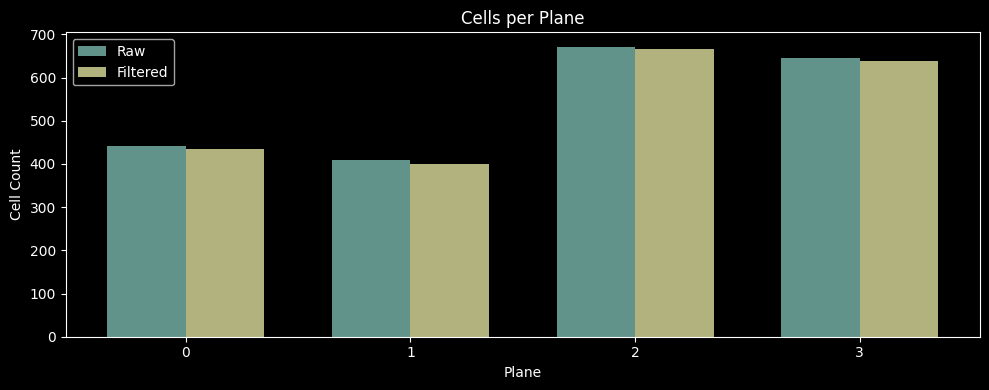

In [27]:
# Cell count per plane
fig, ax = plt.subplots(figsize=(10, 4))

planes = list(range(n_planes))
raw_counts = [plane_results[z]['n_raw'] for z in planes]
filt_counts = [plane_results[z]['n_filtered'] for z in planes]

width = 0.35
ax.bar([p - width/2 for p in planes], raw_counts, width, label='Raw', alpha=0.7)
ax.bar([p + width/2 for p in planes], filt_counts, width, label='Filtered', alpha=0.7)

ax.set_xlabel('Plane')
ax.set_ylabel('Cell Count')
ax.set_title('Cells per Plane')
ax.legend()
ax.set_xticks(planes)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cells_per_plane.png', dpi=150)
plt.show()

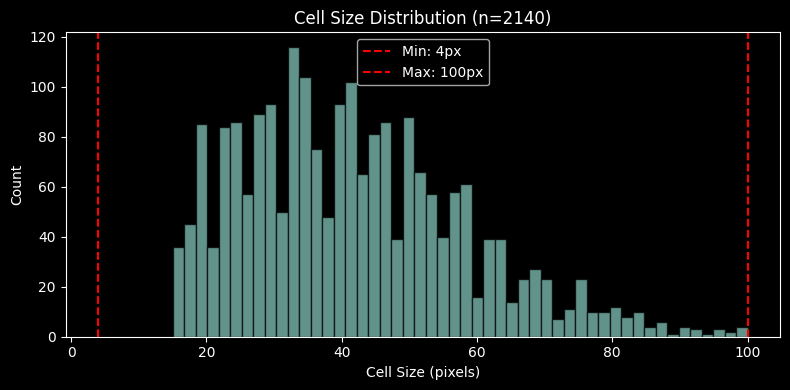

Size stats: min=15, median=40, max=100


In [28]:
# Size distribution
all_sizes = []
for z in range(n_planes):
    for s in plane_results[z]['stat']:
        all_sizes.append(s['npix'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_sizes, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(MIN_CELL_SIZE, color='red', linestyle='--', label=f'Min: {MIN_CELL_SIZE}px')
ax.axvline(MAX_CELL_SIZE, color='red', linestyle='--', label=f'Max: {MAX_CELL_SIZE}px')
ax.set_xlabel('Cell Size (pixels)')
ax.set_ylabel('Count')
ax.set_title(f'Cell Size Distribution (n={len(all_sizes)})')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'size_distribution.png', dpi=150)
plt.show()

print(f"Size stats: min={np.min(all_sizes)}, median={np.median(all_sizes):.0f}, max={np.max(all_sizes)}")

## Output Files

In [ ]:
print("\nOutput files:")
print("="*60)
print(f"\nVolume results:")
print(f"  {OUTPUT_DIR / 'volume_ops.npy'}")
print(f"  {OUTPUT_DIR / 'volume_stat.npy'}")
print(f"  {OUTPUT_DIR / 'volume_iscell.npy'}")

print(f"\nPer-plane results (Suite2p GUI compatible):")
for z in range(min(3, n_planes)):
    print(f"  {OUTPUT_DIR / f'plane{z:02d}'}")
if n_planes > 3:
    print(f"  ... ({n_planes - 3} more planes)")